# Predictive Factors of Waiter Tips Analysis

To analyze customer tipping dynamics through transactional and demographic data using Exploratory Data Analysis (EDA). The objective is to identify key trends, evaluate correlations, and determine how customer profiles and spending habits directly impact gratuity rates.

<img src='https://www.yourtango.com/sites/default/files/image_blog/2025-12/customers-debate-whether-tipping-necessary-eating-out.png' width='750'>

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

### EDA

In [2]:
df=pd.read_csv("waitertips.csv")

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [5]:
df.shape

(244, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [7]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [8]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [9]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [10]:
df.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


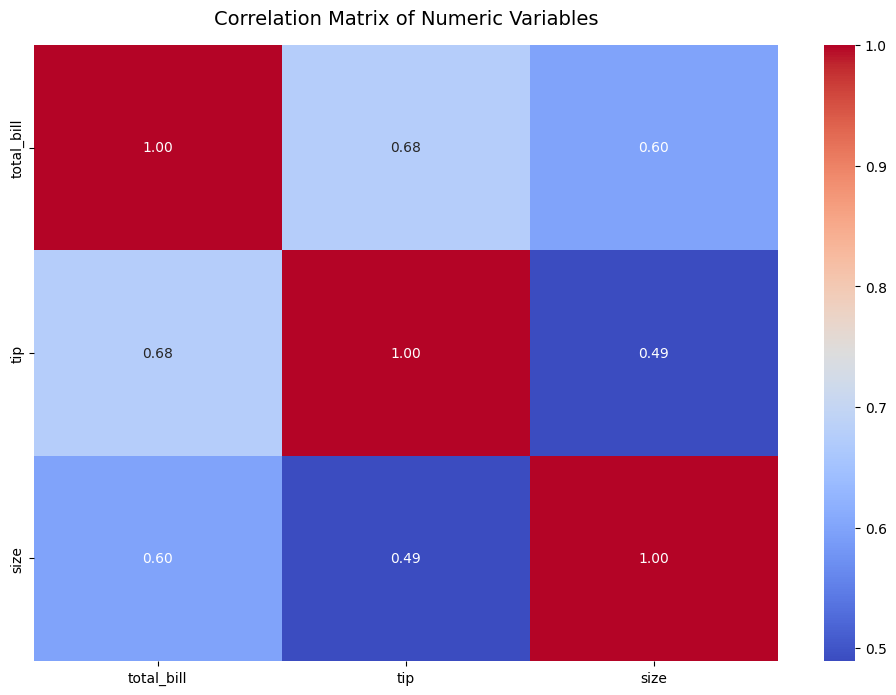

In [13]:
# Heatmap 
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')            
plt.title("Correlation Matrix of Numeric Variables", fontsize=14, pad=15)
plt.show()

In [14]:
df.tip.value_counts()

tip
2.00    33
3.00    23
4.00    12
5.00    10
2.50    10
        ..
4.34     1
1.56     1
5.20     1
2.60     1
1.75     1
Name: count, Length: 123, dtype: int64

In [15]:
df.time.unique()

array(['Dinner', 'Lunch'], dtype=object)

In [16]:
df.time.value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [17]:
df.sex.value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [18]:
df.smoker.value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

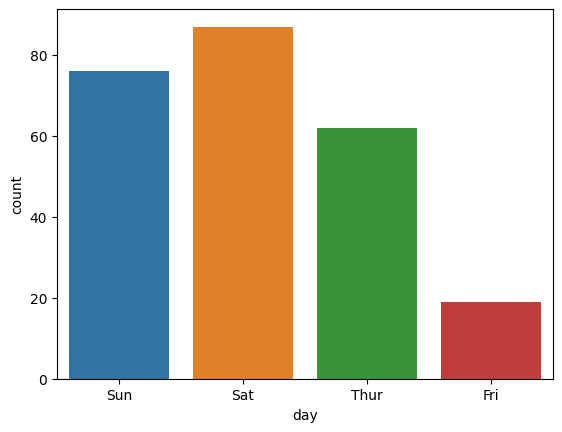

In [19]:
sns.countplot(x=df['day'],hue=df['day']);

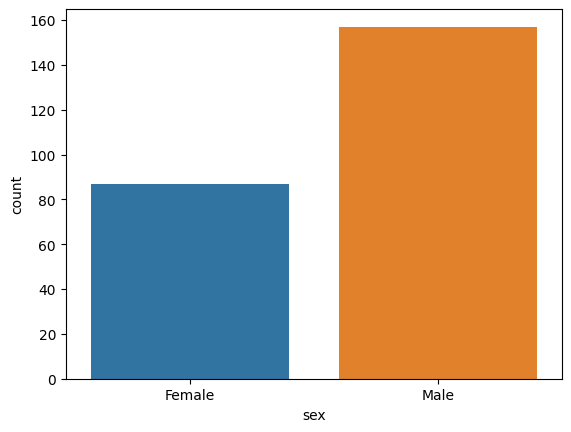

In [20]:
sns.countplot(x=df['sex'],hue=df['sex']);

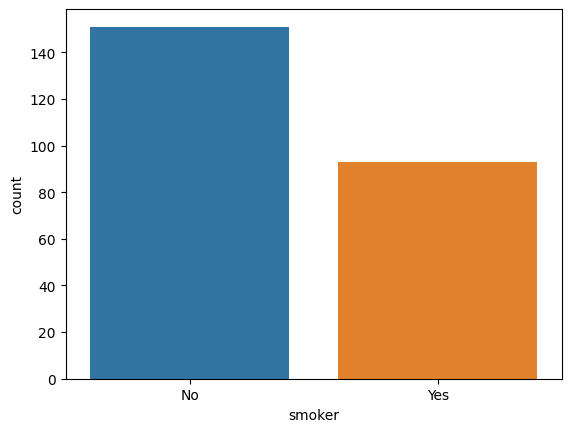

In [21]:
sns.countplot(x=df['smoker'],hue=df['smoker']);

<Axes: xlabel='tip', ylabel='count'>

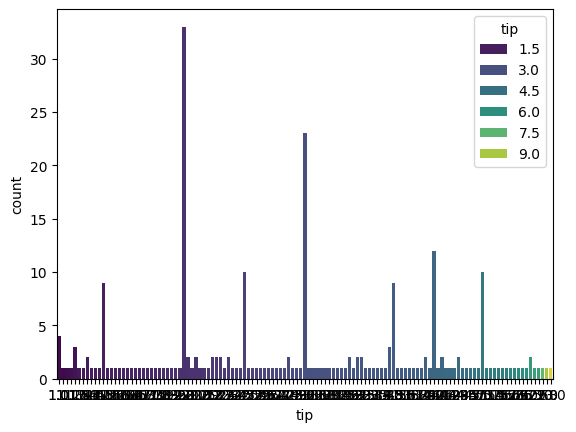

In [22]:
sns.countplot(df, x="tip", hue="tip", palette="viridis")

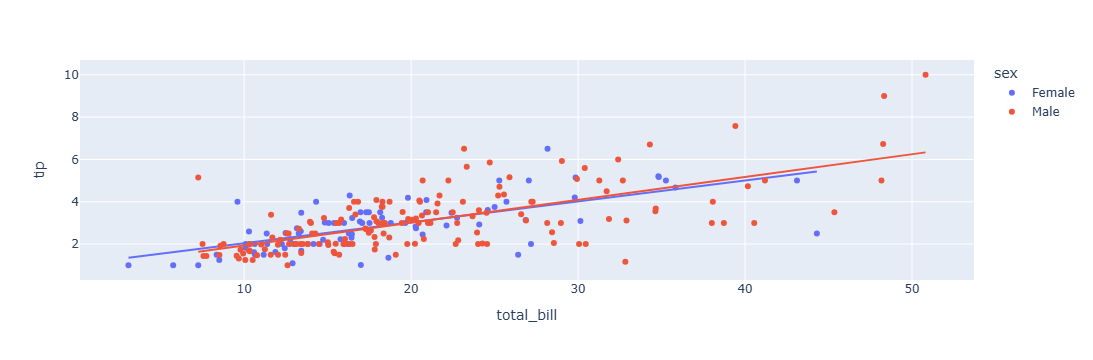

In [23]:
px.scatter(df, x="total_bill", y="tip", color="sex", trendline="ols").show()

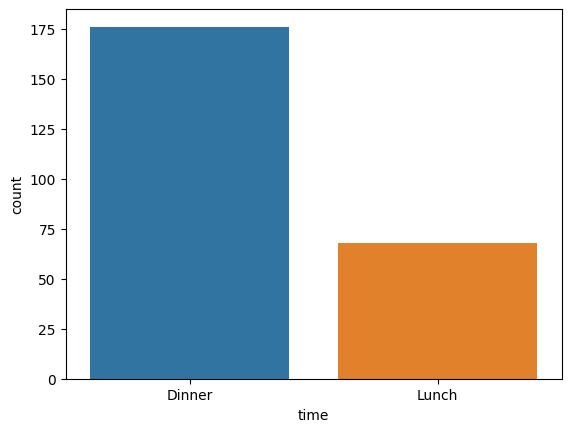

In [24]:
sns.countplot(x=df['time'],hue=df['time']);

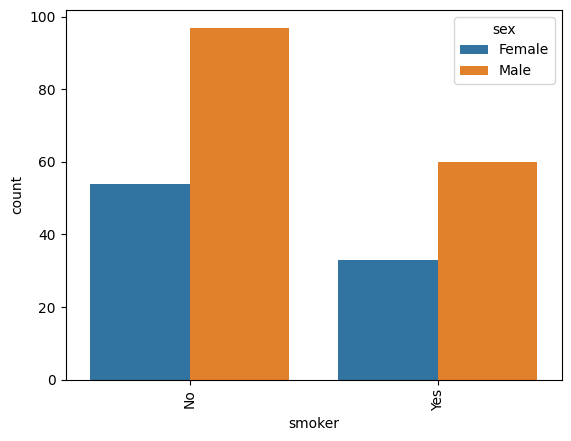

In [25]:
sns.countplot(x=df['smoker'],hue=df['sex']);
plt.xticks(rotation=90);

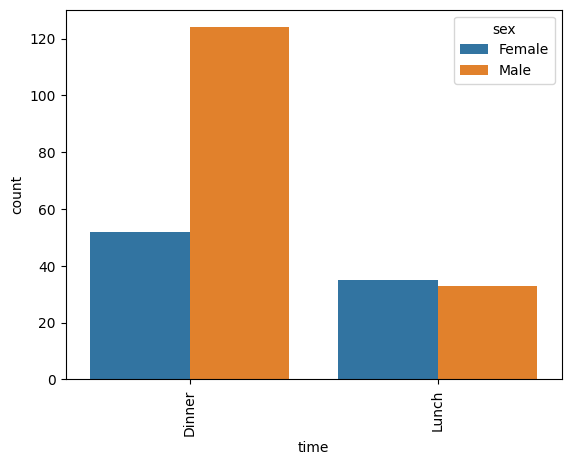

In [26]:
sns.countplot(x=df['time'],hue=df['sex']);
plt.xticks(rotation=90);

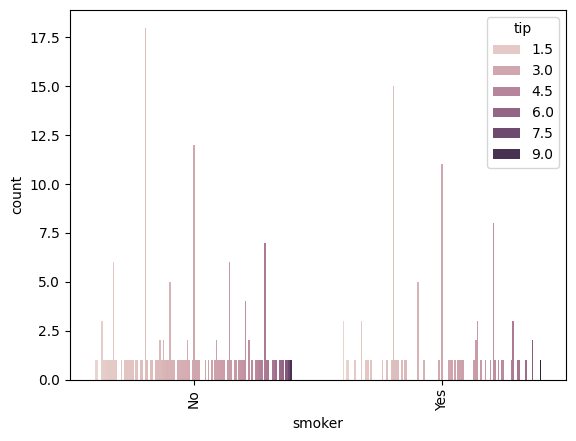

In [27]:
sns.countplot(x=df['smoker'],hue=df['tip']);
plt.xticks(rotation=90);

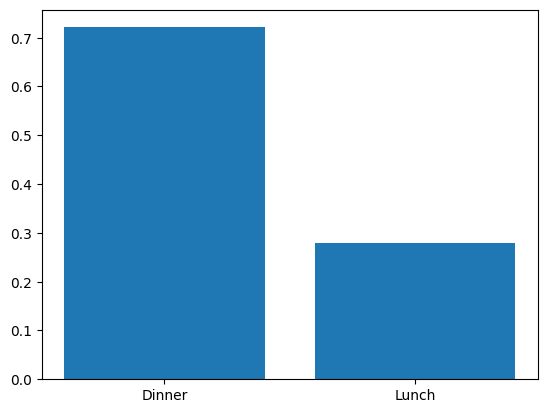

In [28]:
plt.bar(df['time'].unique(),df['time'].value_counts(normalize=True));

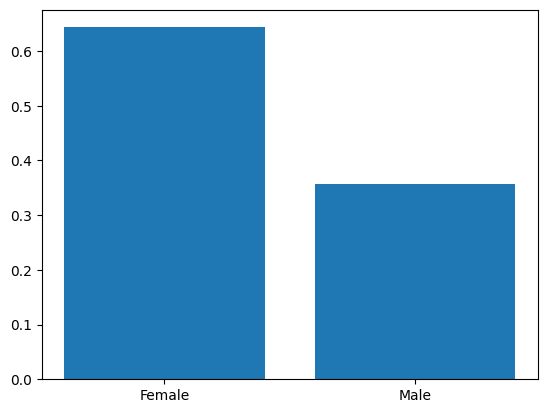

In [29]:
plt.bar(df['sex'].unique(),df['sex'].value_counts(normalize=True));

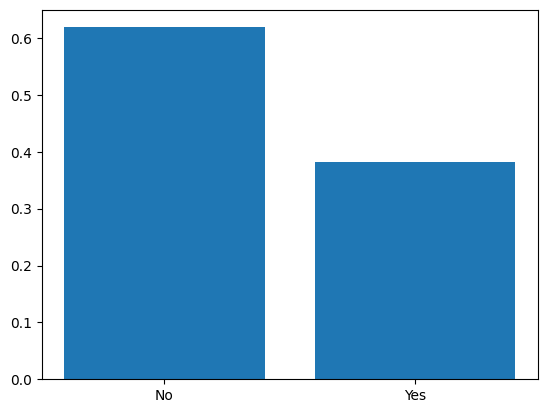

In [30]:
plt.bar(df['smoker'].unique(),df['smoker'].value_counts(normalize=True));

<Axes: xlabel='tip', ylabel='Probability'>

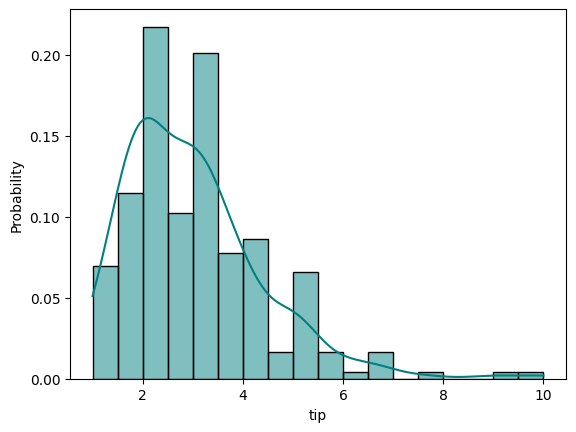

In [33]:
sns.histplot(df, x="tip", stat="probability", kde=True, color="teal")

<Axes: xlabel='total_bill', ylabel='Probability'>

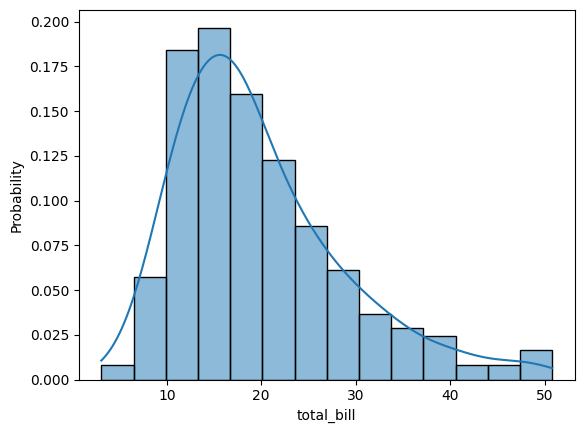

In [32]:
sns.histplot(df, x="total_bill", stat="probability", kde=True, palette="viridis")

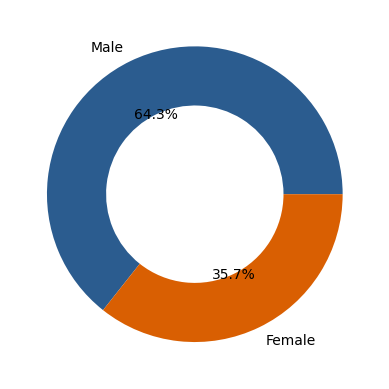

In [35]:
plt.pie(
    df["sex"].value_counts(),
    labels=df["sex"].value_counts().index,
    autopct="%1.1f%%",
    colors=["#2b5c8f", "#d95f02"],
    wedgeprops={"width": 0.4},
);

<Axes: title={'center': 'Smoker Distribution'}>

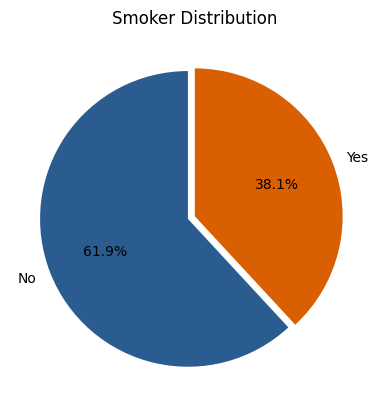

In [36]:
df["smoker"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2b5c8f", "#d95f02"],
    explode=(0.05, 0),
    ylabel="",
    title="Smoker Distribution",
)

Text(0, 0.5, 'Frequency')

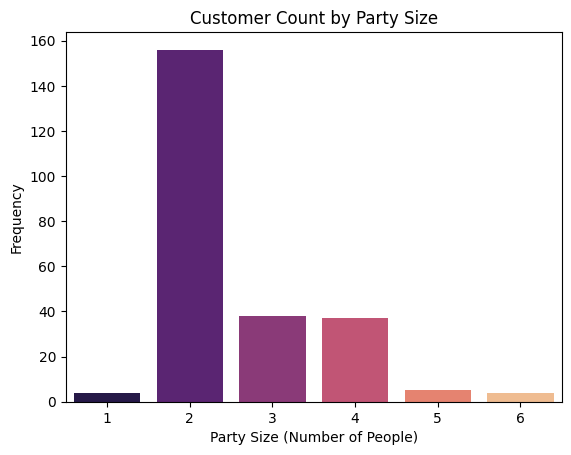

In [39]:
sns.countplot(df, x="size", palette="magma")
plt.title("Customer Count by Party Size")
plt.xlabel("Party Size (Number of People)")
plt.ylabel("Frequency")

<Axes: title={'center': 'Meal Time Distribution (Lunch vs Dinner)'}>

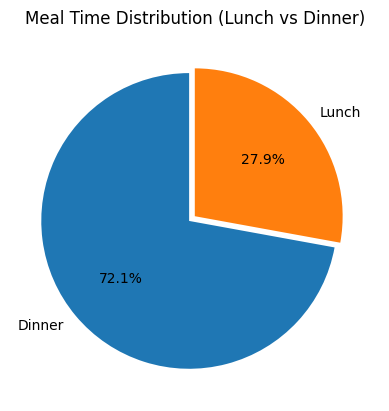

In [40]:
df["time"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=["#1f77b4", "#ff7f0e"],
    explode=(0.05, 0),
    ylabel="",
    title="Meal Time Distribution (Lunch vs Dinner)",
)

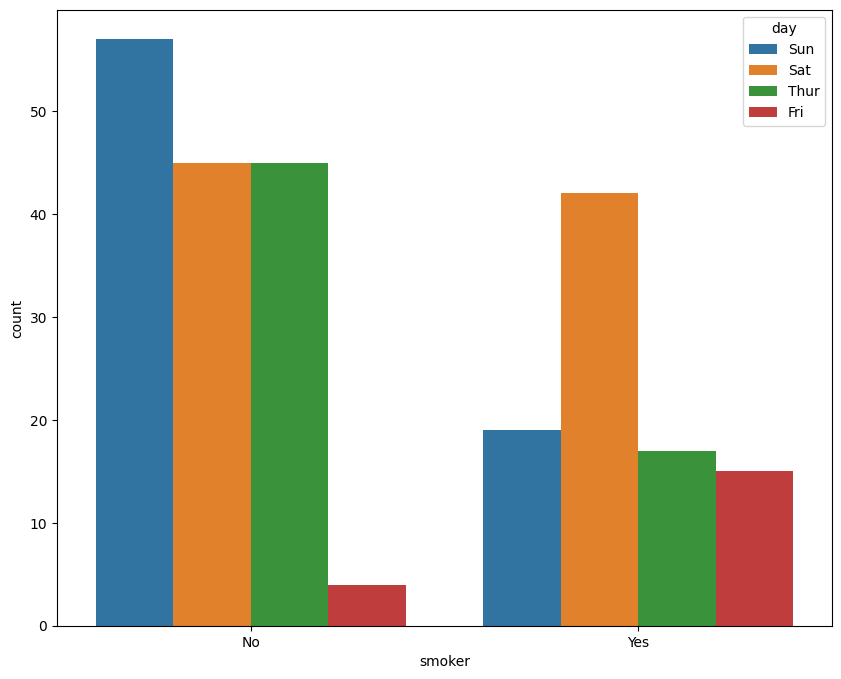

In [41]:
plt.figure(figsize=(10,8))
sns.countplot(x=df['smoker'],hue=df['day']);

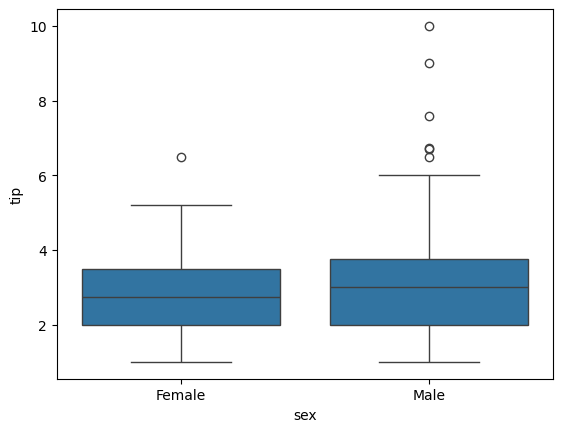

In [42]:
sns.boxplot(x='sex',y='tip',data=df);

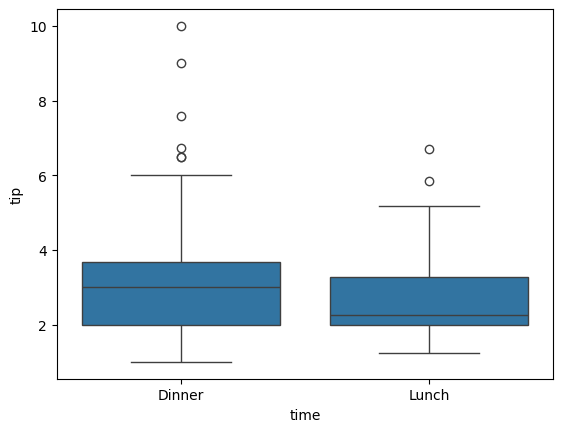

In [43]:
sns.boxplot(x='time',y='tip',data=df);

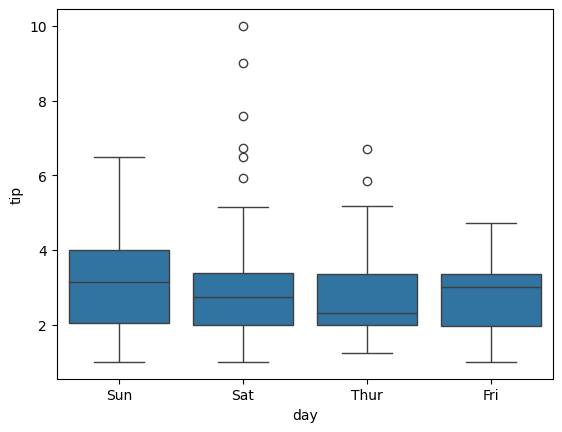

In [44]:
sns.boxplot(x='day',y='tip',data=df);

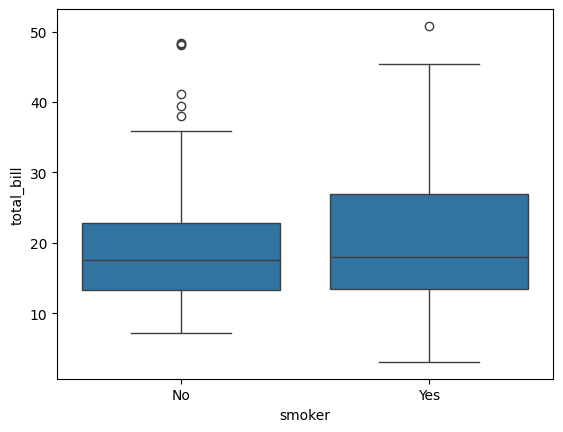

In [45]:
sns.boxplot(x='smoker',y='total_bill',data=df);

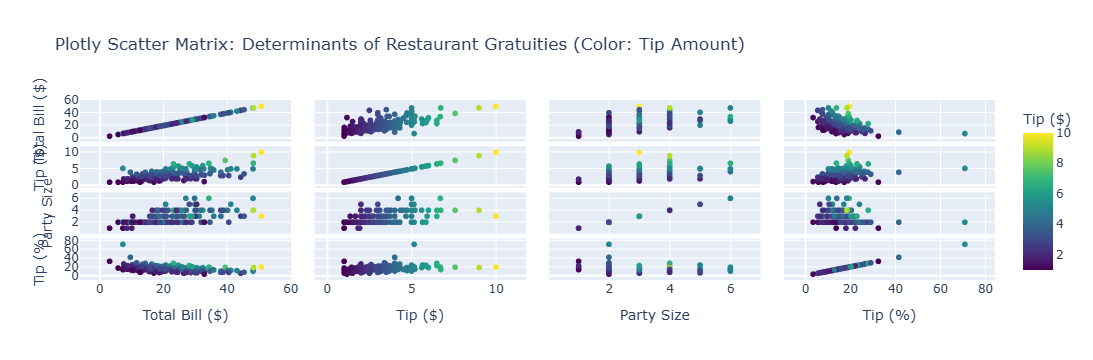

In [48]:
import plotly.express as px

# Load dataset and calculate tip percentage
df = px.data.tips()
df["tip_percent"] = (df["tip"] / df["total_bill"]) * 100

# Scatter Matrix
fig = px.scatter_matrix(
    df,
    dimensions=["total_bill", "tip", "size", "tip_percent"],
    color="tip",
    color_continuous_scale="Viridis",
    title="Plotly Scatter Matrix: Determinants of Restaurant Gratuities (Color: Tip Amount)",
    labels={
        "total_bill": "Total Bill ($)",
        "tip": "Tip ($)",
        "size": "Party Size",
        "tip_percent": "Tip (%)",
    },
)

fig.update_traces(diagonal_visible=True)
fig.show()

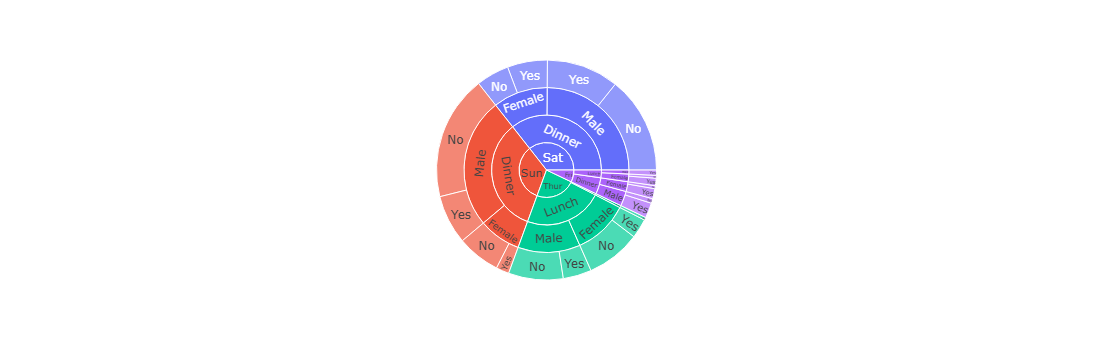

In [49]:
px.sunburst(df,path=['day','time','sex','smoker'],values='tip')

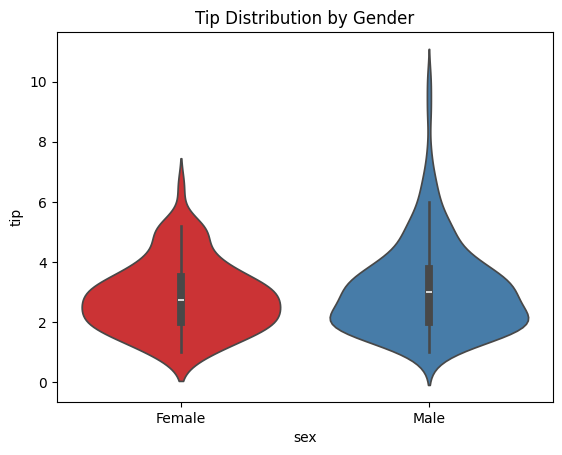

In [50]:
# The "Seaborn Way"
sns.violinplot(data=df, x='sex', y='tip', palette='Set1')
plt.title('Tip Distribution by Gender')
plt.show()

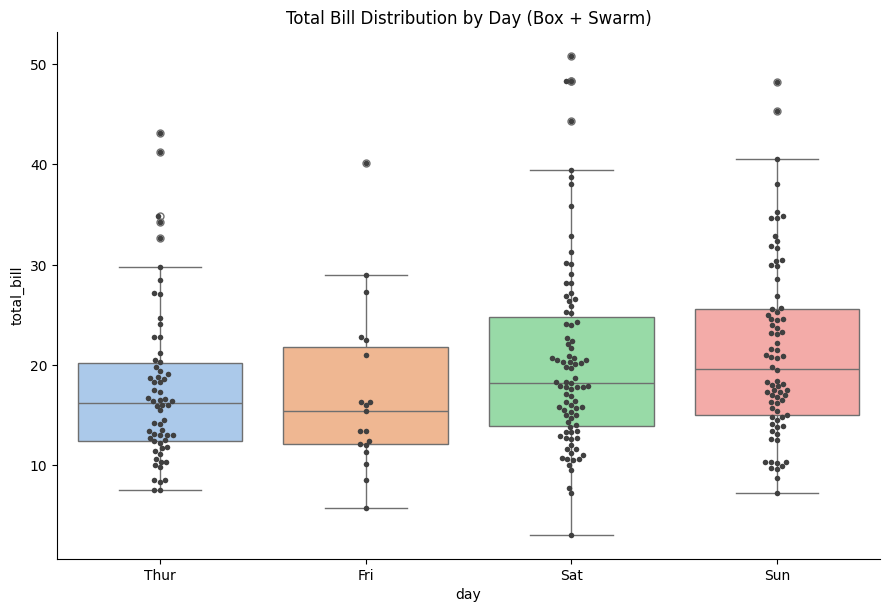

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
tips = sns.load_dataset("tips")

# Create a categorical plot grid
g = sns.catplot(
    data=tips,
    x="day",
    y="total_bill",
    kind="box",
    palette="pastel",
    height=6,
    aspect=1.5,
)

# Overlay swarmplot on top of the boxplot axes
sns.swarmplot(
    data=tips, x="day", y="total_bill", color=".25", size=4, ax=g.ax
)

plt.title("Total Bill Distribution by Day (Box + Swarm)")
plt.show()

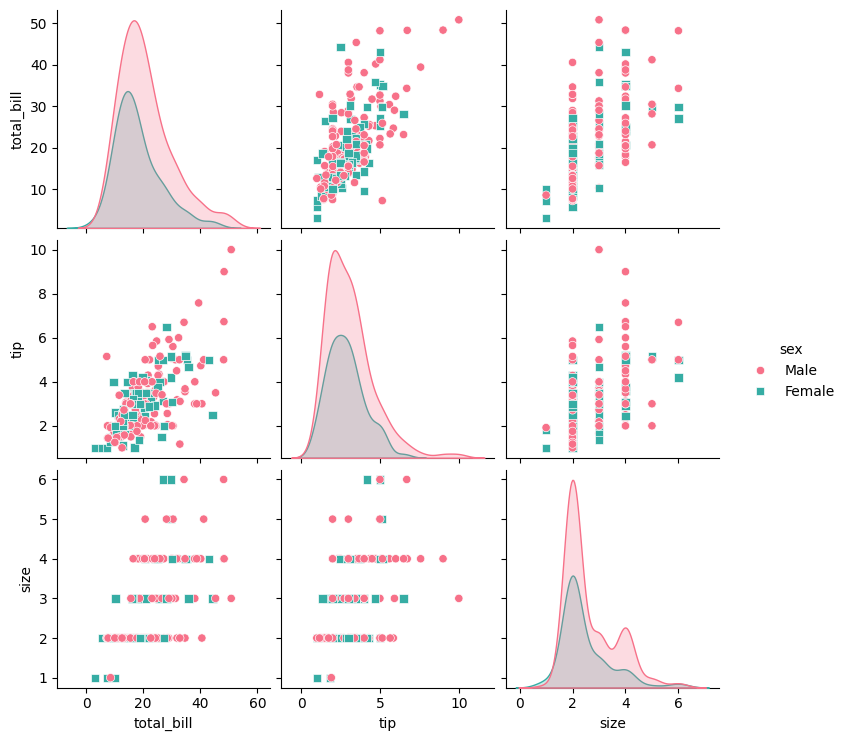

In [52]:
sns.pairplot(tips, hue="sex", palette="husl", markers=["o", "s"]);
# Tips with respect to genders

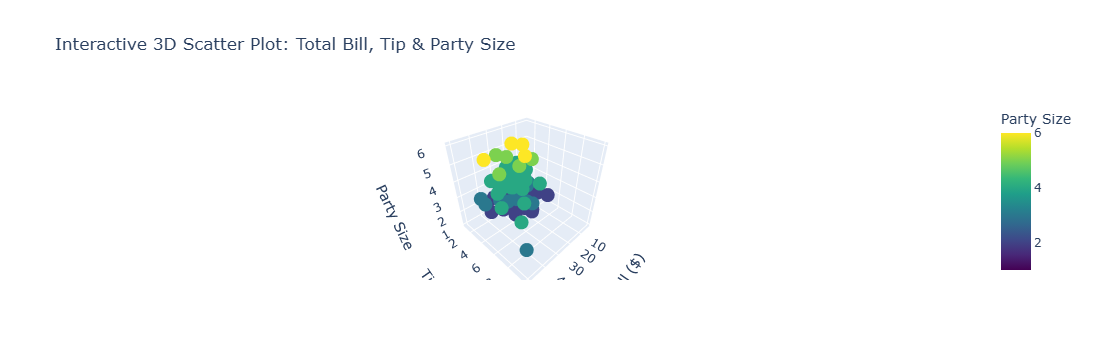

In [53]:
import plotly.express as px

# Load dataset
tips = px.data.tips()

# Interactive 3D Scatter Plot
fig = px.scatter_3d(
    tips,
    x="total_bill",
    y="tip",
    z="size",
    color="size",
    color_continuous_scale="Viridis",
    title="Interactive 3D Scatter Plot: Total Bill, Tip & Party Size",
    labels={
        "total_bill": "Total Bill ($)",
        "tip": "Tip ($)",
        "size": "Party Size",
    },
)

# Render plot
fig.show()

This Exploratory Data Analysis demonstrates that gratuity levels are far from random, revealing structured patterns driven primarily by transaction magnitude alongside distinct temporal and demographic trends. By leveraging interactive multidimensional visualizations—such as 3D scatter matrices and hierarchical Sunburst charts—we moved beyond surface-level metrics to uncover deeper customer behavior dynamics. Building upon these findings, the next phase focuses on deploying an interactive Streamlit web dashboard, enabling real-time exploration and making these analytical insights actionable for operational decision-making.